## TEST Finetune on random images

In [2]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
import os
import requests

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

# check whether run in Colab
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip3 install timm==0.4.5  # 0.3.2 does not work in Colab
    !git clone https://github.com/facebookresearch/mae.git
    sys.path.append('./mae')
else:
    sys.path.append('..')
import models_vit

from pytorch_grad_cam import GradCAM,HiResCAM,ScoreCAM,GradCAMPlusPlus,AblationCAM,XGradCAM,EigenCAM,FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])


/home/imt-humanis/anaconda3/envs/visapp1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## UTILITY FUNCTIONS

In [3]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def prepare_model(chkpt_dir, arch='mae_vit_large_patch16'):
    # build model
    model = models_vit.__dict__[arch](
        num_classes=2,
        global_pool=False,
    )
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def run_one_image(img, model):
    x = torch.tensor(img)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    y = model(x.float())
    return y 

In [4]:
#################################################
chkpt_dir = './finetune3/best_model.pth'
model_mae_classif = prepare_model(chkpt_dir, 'vit_large_patch16')

<All keys matched successfully>


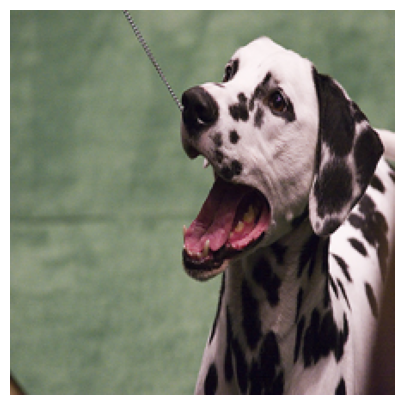

In [9]:
img_path = "../../data/cat_dog/test/dog/50.jpg"
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.

assert img_float.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_float - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [10]:
result = run_one_image(img_tsf, model_mae_classif)
# Optionally compute probabilities
probabilities = torch.softmax(result, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['cat', 'dog']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)


Probabilities: tensor([[0.0491, 0.9509]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([1])
Predicted classes: ['dog']


## GRAD CAM CHECKING

torch.Size([3, 224, 224])


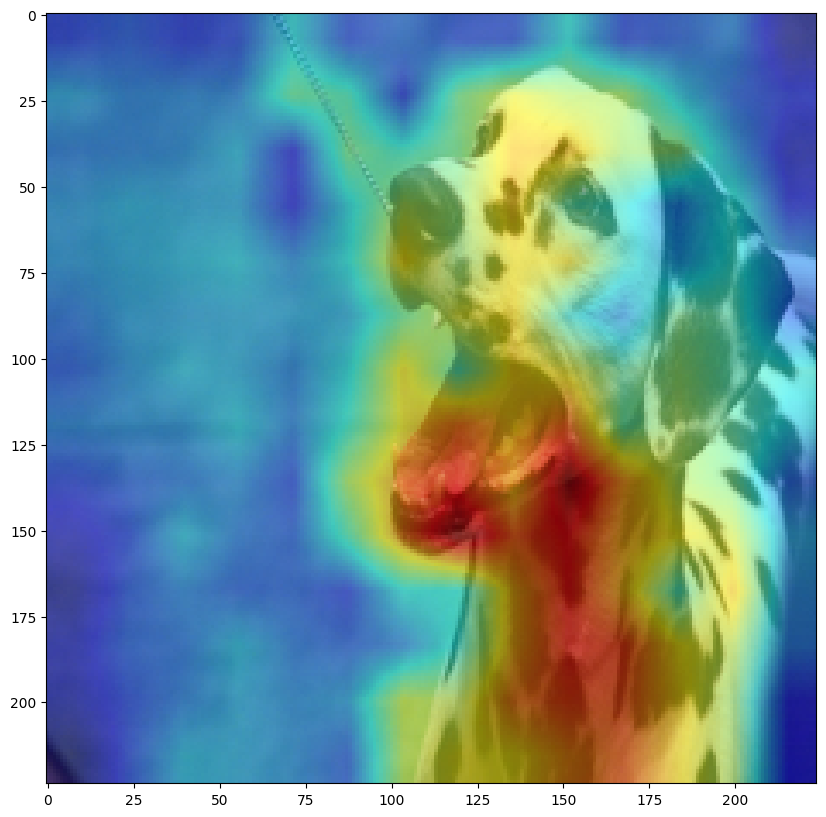

In [11]:
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1 :  , :].reshape(tensor.size(0),
        height, width, tensor.size(2))

    # Bring the channels to the first dimension,
    # like in CNNs.
    result = result.transpose(2, 3).transpose(1, 2)
    return result

trsfm = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(), # convert between 0 and 1
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

        ])

#img_torch = torch.from_numpy(img_float)
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif.blocks[-1].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam = GradCAM(model=model_mae_classif,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)



plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
plt.imshow(visualization)

## RAILSEM TEST FROM HERE

In [14]:
#################################################
chkpt_dir_railsem = './finetune/finetune_railsem4_balanced_10000/best_model.pth'
model_mae_classif_railsem = prepare_model(chkpt_dir_railsem, 'vit_base_patch16')

<All keys matched successfully>


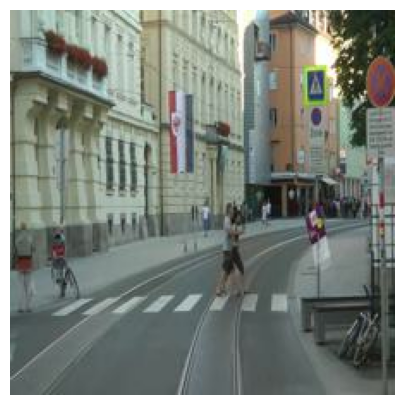

In [20]:
#img_path = "../../data/images/2vsall/test/risky/rs00184.jpg" ##RAILSEM19 TRAINING
img_path = "../../data/images/2vsall_bl_2/test/risky/rs03574.jpg"#railsem balanced
#img_path = "../../data/images/rs19_224/rs00202.jpg" ##RAILSEM19 ALL
#img_path="../../data/cat_dog/test/cat/94.jpg" ##CATDOG
#img_path = "../../data/simulator/synthetic/3_forest/images/8.png" ##SIMULATOR
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.
img_jpg = img_float[:,:,:3]

assert img_jpg.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_jpg - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [21]:
result = run_one_image(img_tsf, model_mae_classif_railsem)
# Optionally compute probabilities
probabilities = torch.softmax(result, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['risky', 'safe']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)

Probabilities: tensor([[0.9618, 0.0382]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['risky']


### Grad cam checking

torch.Size([3, 224, 224])


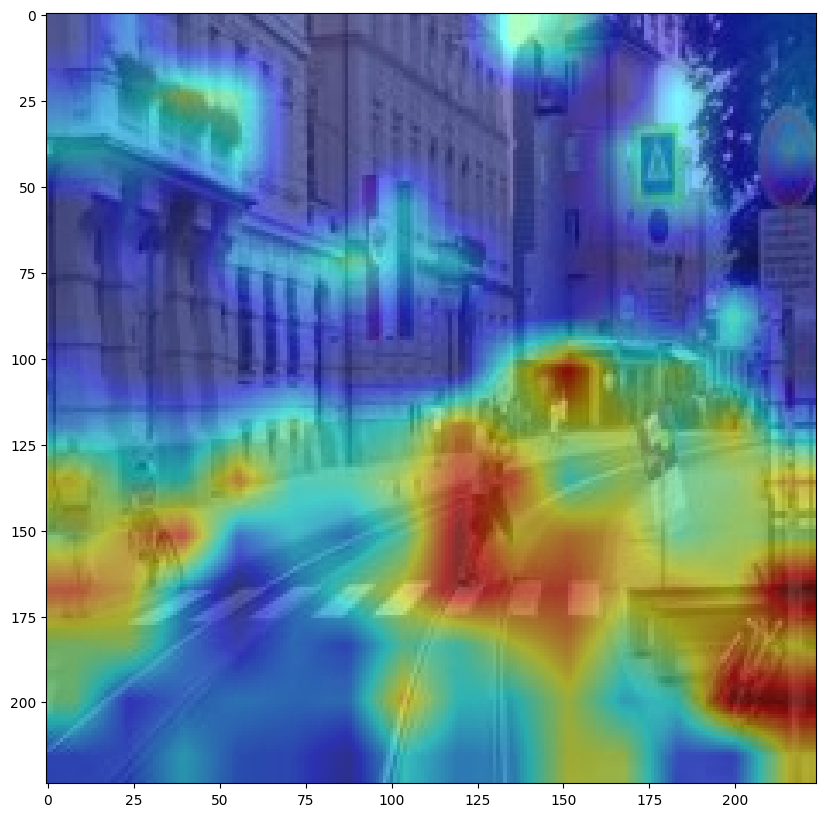

In [22]:
#img_torch = torch.from_numpy(img_float)
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif_railsem.blocks[-1].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam = GradCAM(model=model_mae_classif_railsem,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)



plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
plt.imshow(visualization)